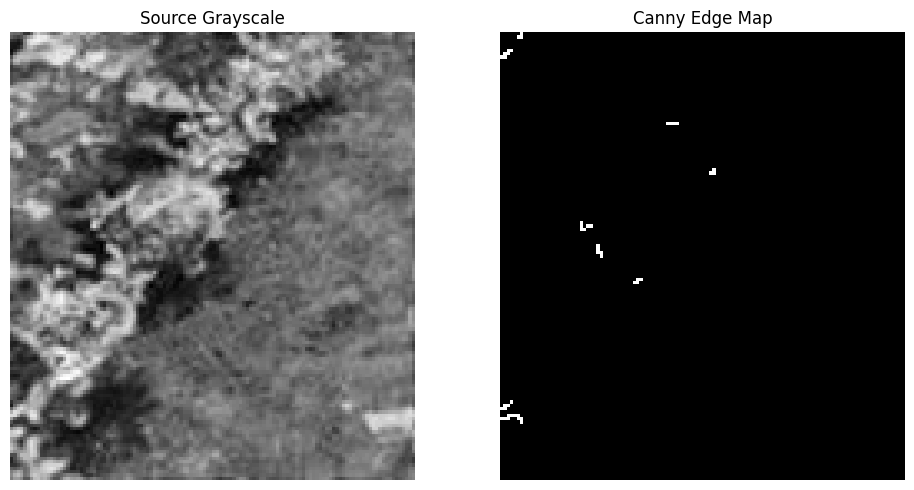

In [ ]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

# 1. Load the target image segment in grayscale mode
source_img = cv.imread('Picture1.jpg', cv.IMREAD_GRAYSCALE)

# 2. Execute Canny edge detection
# Using a low threshold of 550 and a high threshold of 690
edge_mask = cv.Canny(source_img, 550, 690)

# 3. Visualize the comparison between the source and the edge map
plt.figure(figsize=(10, 5))

# Display original grayscale image
plt.subplot(1, 2, 1)
plt.imshow(source_img, cmap='gray')
plt.title('Source Grayscale')
plt.axis('off')

# Display the binary edge result
plt.subplot(1, 2, 2)
plt.imshow(edge_mask, cmap='gray')
plt.title('Canny Edge Map')
plt.axis('off')

plt.tight_layout()
plt.show()

# 4. Map the non-zero pixel locations to coordinate arrays
# row_indices corresponds to Y, col_indices corresponds to X
row_indices, col_indices = np.nonzero(edge_mask)
x = col_indices
y = row_indices

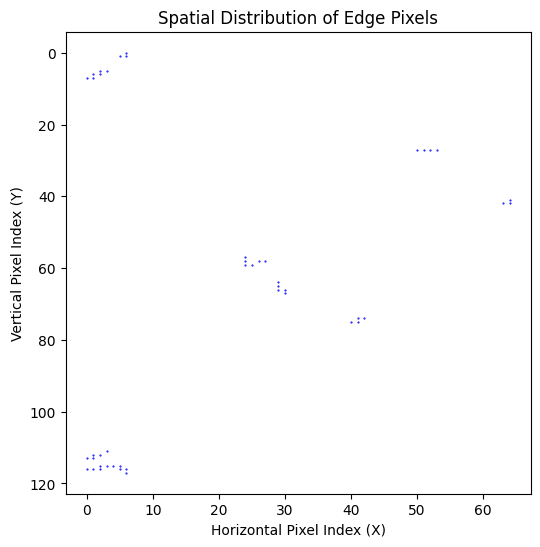

In [ ]:
import matplotlib.pyplot as plt

# Initialize a square figure for consistent aspect ratio
fig, ax = plt.subplots(figsize=(6, 6))

# Generate the scatter plot using the coordinate arrays
# 's=1' ensures the points are small enough to resemble lines
ax.scatter(x, y, s=1, c='blue', marker='.')

# Standardize the plot aesthetics
ax.set_title('Spatial Distribution of Edge Pixels')
ax.set_xlabel('Horizontal Pixel Index (X)')
ax.set_ylabel('Vertical Pixel Index (Y)')

# Flip the Y-axis to align with standard image coordinate systems
ax.invert_yaxis()

# Display the final plot
plt.show()

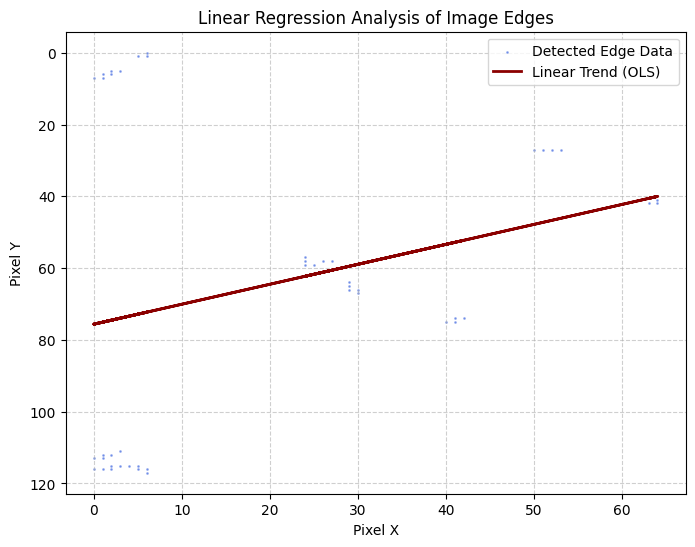

In [ ]:
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt

# 1. Transform X into a column vector (required for scikit-learn features)
X_features = x.reshape(-1, 1)

# 2. Instantiate the regressor and calculate the Ordinary Least Squares (OLS) fit
regressor = LinearRegression()
regressor.fit(X_features, y)

# 3. Generate the trend line coordinates based on the model's coefficients
y_trend = regressor.predict(X_features)

# 4. Visualization
plt.figure(figsize=(8, 6))

# Plot the raw edge data points
plt.scatter(x, y, s=1, color='royalblue', alpha=0.5, label='Detected Edge Data')

# Overlay the regression line
plt.plot(x, y_trend, color='darkred', lw=2, label='Linear Trend (OLS)')

# Formatting to maintain image-space consistency
plt.title('Linear Regression Analysis of Image Edges')
plt.xlabel('Pixel X')
plt.ylabel('Pixel Y')
plt.gca().invert_yaxis()
plt.legend(loc='upper right')

plt.grid(True, linestyle='--', alpha=0.6) # Added grid for easier coordinate reading
plt.show()

In [ ]:
import numpy as np

# 1. Retrieve the gradient (m) from the trained model
m_gradient = regressor.coef_[0]

# 2. Compute the inclination angle using the arctangent function
# This returns the angle in radians, which we then convert to degrees
theta_radians = np.arctan(m_gradient)
theta_degrees = np.degrees(theta_radians)

# 3. Derive alternate geometric representations
# Magnitude (absolute tilt) and the 180-degree reference angle
abs_inclination = abs(theta_degrees)
geometric_ref_angle = 180 + theta_degrees

# 4. Results Output
print(f"{' Result Analysis ':—^30}")
print(f"Regression Gradient (m):    {m_gradient:.4f}")
print(f"Angular Orientation:        {theta_degrees:.2f}°")
print(f"Absolute Tilt Magnitude:    {abs_inclination:.2f}°")


—————— Result Analysis ———————
Regression Gradient (m):    -0.5562
Angular Orientation:        -29.08°
Absolute Tilt Magnitude:    29.08°


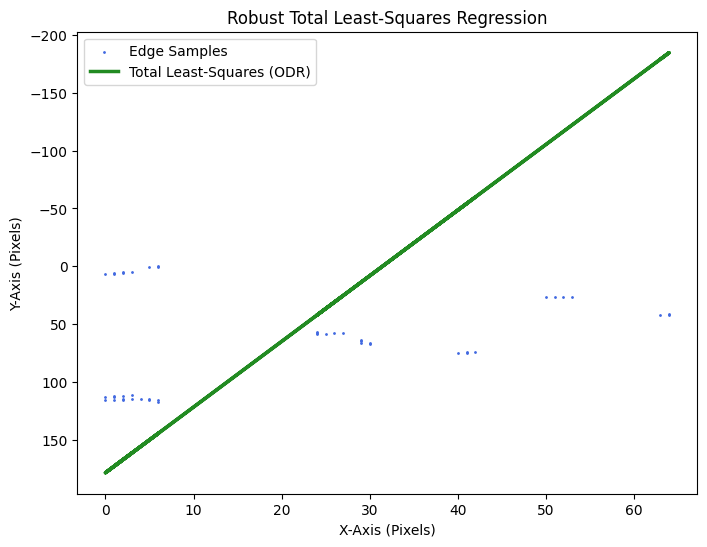

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import odr

# 1. Define the linear model: y = m*x + c
# 'p' is a list of parameters: p[0] is slope, p[1] is intercept
def model_fit(params, x_input):
    return params[0] * x_input + params[1]

# 2. Package the data and the model for the ODR solver
linear_structure = odr.Model(model_fit)
observation_data = odr.Data(x, y)

# 3. Configure the Orthogonal Distance Regression (ODR)
# beta0 provides the starting guesses for [slope, intercept]
odr_session = odr.ODR(observation_data, linear_structure, beta0=[-1.0, 100.0])

# 4. Execute the optimization and retrieve results
results = odr_session.run()
m_tls, c_tls = results.beta

# 5. Generate the regression line for plotting
y_trend_tls = m_tls * x + c_tls

# 6. Visualization
plt.figure(figsize=(8, 6))

# Plot the raw edge points
plt.scatter(x, y, s=1, color='royalblue', label='Edge Samples')

# Plot the TLS line (green)
plt.plot(x, y_trend_tls, color='forestgreen', lw=2.5, label='Total Least-Squares (ODR)')

# Adjust for image coordinate space
plt.title('Robust Total Least-Squares Regression')
plt.xlabel('X-Axis (Pixels)')
plt.ylabel('Y-Axis (Pixels)')
plt.gca().invert_yaxis()
plt.legend(frameon=True)

plt.show()

In [ ]:
import numpy as np

# 1. Transform the TLS slope (m) into an angular measurement
# arctan gives the angle in radians; we convert it to degrees for readability
theta_tls_rad = np.arctan(m_tls)
theta_tls_deg = np.degrees(theta_tls_rad)

# 2. Derive the absolute orientation (magnitude)
# This is useful for describing the tilt regardless of the direction
abs_tilt_tls = abs(theta_tls_deg)

# 3. Formatted Reporting
print(f"{' TLS Geometric Analysis ':=^35}")
print(f"Refined Slope (m):           {m_tls:.4f}")
print(f"True Orientation (Raw):      {theta_tls_deg:.2f}°")
print(f"True Orientation (Absolute): {abs_tilt_tls:.2f}°")
print("=" * 35)

===== TLS Geometric Analysis ======
Refined Slope (m):           -5.6750
True Orientation (Raw):      -80.01°
True Orientation (Absolute): 80.01°
